# Bidirectional Sequence Modeling on IMDb — Hugging Face

## Bidirectional LSTM + Bidirectional GRU

NLP sequence-modeling project using the **IMDb Large Movie Review Dataset** from Hugging Face.

### Models
- Bidirectional LSTM
- Bidirectional GRU

### Evaluation
- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix
- ROC curve
- AUC
- Training/validation accuracy and loss
- Model comparison

The IMDb dataset has `text` and binary `label` fields (`0 = neg`, `1 = pos`) with 25,000 train and 25,000 test examples.

In [1]:
# Install once in Colab/Kaggle if necessary
# !pip install -q datasets tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

## 1. Imports and configuration

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

VOCAB_SIZE = 20000
MAX_LEN = 200
EMBED_DIM = 128
LSTM_UNITS = 64
GRU_UNITS = 64
BATCH_SIZE = 64
EPOCHS = 8

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 2. Load IMDb from Hugging Face

In [3]:
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)
print(dataset["train"][0])
print(dataset["test"][0])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and

## 3. Convert to DataFrames and inspect

In [4]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

print("\nLabel distribution:")
print(train_df["label"].value_counts().sort_index())

Train shape: (25000, 2)
Test shape : (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0



Label distribution:
label
0    12500
1    12500
Name: count, dtype: int64


## 4. Text cleaning

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9!?.,'\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

display(train_df[["text", "clean_text", "label"]].head())

,text,clean_text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...,0
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard's ma...,0
4,"Oh, brother...after hearing about this ridicul...","oh, brother...after hearing about this ridicul...",0


## 5. Train/validation split

The official IMDb dataset already provides train and test splits. We keep the official test set untouched and split only the training data into training and validation sets. This avoids using the test set during model selection. citeturn0search0turn0search5

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_df["clean_text"].values,
    train_df["label"].values,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"].values
)

X_test = test_df["clean_text"].values
y_test = test_df["label"].values

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 20000
Validation: 5000
Test: 25000


## 6. TextVectorization

In [7]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize=None
)

vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(256))

vocab = vectorizer.get_vocabulary()
print("Vocabulary size:", len(vocab))
print("First 20 tokens:", vocab[:20])

Vocabulary size: 20000
First 20 tokens: ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('and'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('i'), np.str_('this'), np.str_('it'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('for'), np.str_('with'), np.str_('but'), np.str_('on'), np.str_('movie')]


## 7. Build TensorFlow datasets

In [8]:
def make_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(len(texts), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

print("Datasets ready.")

Datasets ready.


## 8. Bidirectional LSTM architecture

A Bidirectional LSTM processes the sequence in both directions:

**Forward:** left → right

**Backward:** right → left

The two hidden representations are combined before classification.

Architecture:

`Text → Vectorization → Embedding → Bidirectional(LSTM) → Dropout → Dense → Sigmoid`

In [9]:
def build_bilstm():
    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="text")
    x = vectorizer(inputs)
    x = tf.keras.layers.Embedding(
        input_dim=len(vocab),
        output_dim=EMBED_DIM,
        mask_zero=True,
        name="embedding"
    )(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(LSTM_UNITS),
        name="bidirectional_lstm"
    )(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs, name="BiLSTM_IMDb")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()

Model: "BiLSTM_IMDb"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 200)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm  │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bidirectional_ls… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Callbacks and training

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "best_bilstm.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

history_bilstm = bilstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.7765 - loss: 0.4484 - val_accuracy: 0.8664 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9194 - loss: 0.2128 - val_accuracy: 0.8588 - val_loss: 0.3593 - learning_rate: 0.0010
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9749 - loss: 0.0769 - val_accuracy: 0.8580 - val_loss: 0.4491 - learning_rate: 5.0000e-04


## 10. BiLSTM training visualization

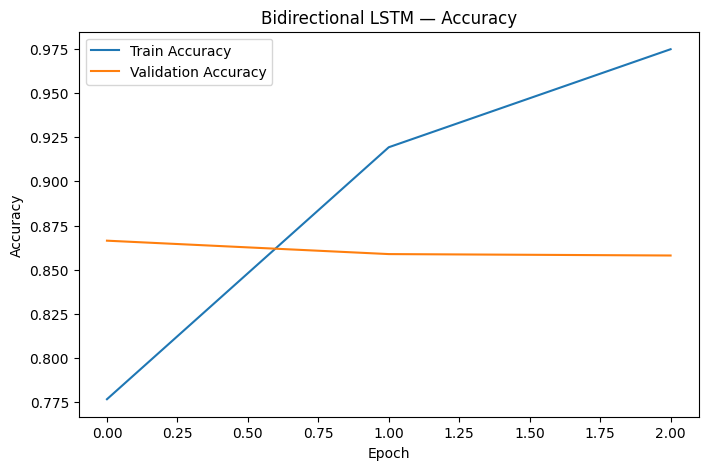

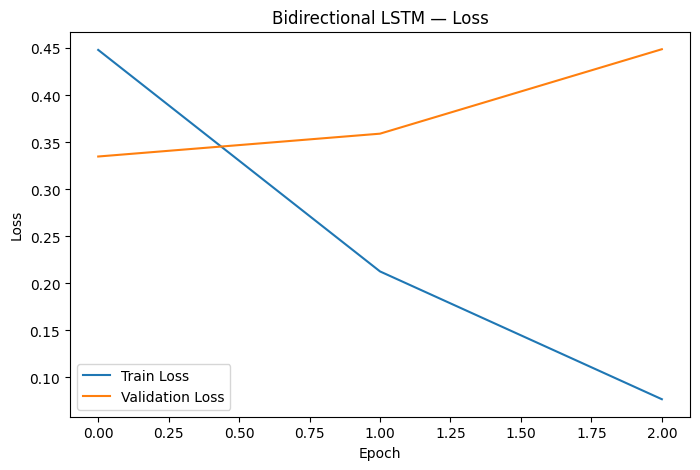

In [11]:
def plot_history(history, title):
    h = history.history
    plt.figure(figsize=(8,5))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.title(title + " — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_bilstm, "Bidirectional LSTM")

## 11. Build Bidirectional GRU

GRU is another gated recurrent sequence model. The bidirectional version reads the sequence from both directions.

Architecture:

`Text → Vectorization → Embedding → Bidirectional(GRU) → Dropout → Dense → Sigmoid`

In [12]:
def build_bigru():
    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="text")
    x = vectorizer(inputs)
    x = tf.keras.layers.Embedding(
        input_dim=len(vocab),
        output_dim=EMBED_DIM,
        mask_zero=True,
        name="embedding"
    )(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(GRU_UNITS),
        name="bidirectional_gru"
    )(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs, name="BiGRU_IMDb")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

bigru_model = build_bigru()
bigru_model.summary()

Model: "BiGRU_IMDb"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 200)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 200)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_gru   │ (None, 128)       │     74,496 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ bidirectional_gr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,642,817 (10.08 MB)

 Trainable params: 2,642,817 (10.08 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Train BiGRU

In [13]:
callbacks_gru = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=2, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "best_bigru.keras"),
        monitor="val_accuracy", save_best_only=True
    )
]

history_bigru = bigru_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_gru
)

Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.7132 - loss: 0.5242 - val_accuracy: 0.8562 - val_loss: 0.3324 - learning_rate: 0.0010
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9108 - loss: 0.2351 - val_accuracy: 0.8560 - val_loss: 0.3397 - learning_rate: 0.0010
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9704 - loss: 0.0905 - val_accuracy: 0.8628 - val_loss: 0.4360 - learning_rate: 5.0000e-04


## 13. BiGRU training visualization

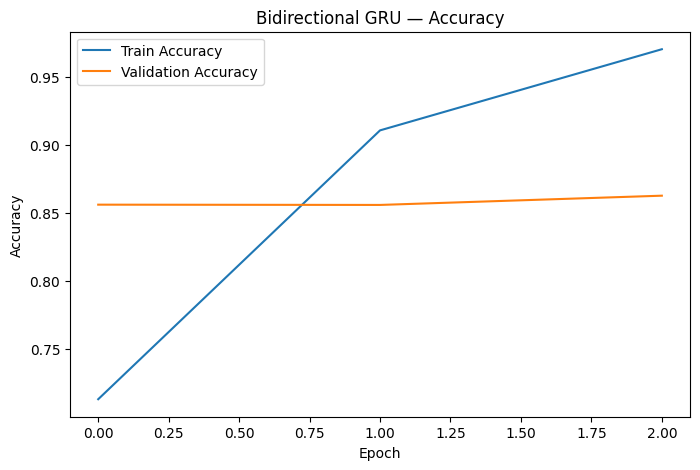

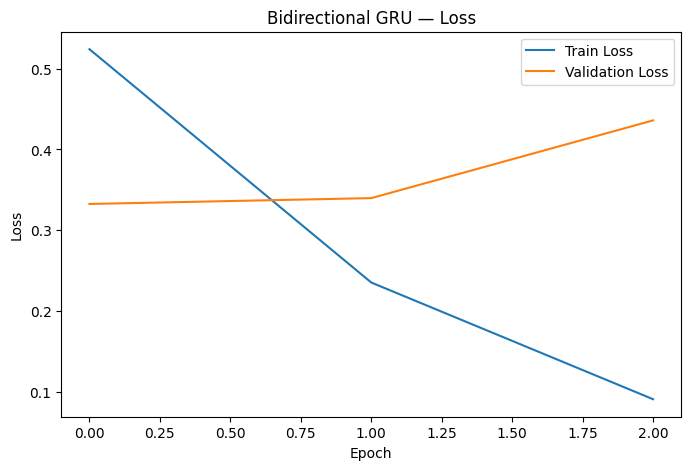

In [14]:
plot_history(history_bigru, "Bidirectional GRU")

## 14. Evaluation helper

In [15]:
def evaluate_model(model, test_ds, y_true):
    prob = model.predict(test_ds, verbose=1).ravel()
    pred = (prob >= 0.5).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "AUC": roc_auc_score(y_true, prob)
    }
    return metrics, pred, prob

bilstm_metrics, bilstm_pred, bilstm_prob = evaluate_model(
    bilstm_model, test_ds, y_test
)
bigru_metrics, bigru_pred, bigru_prob = evaluate_model(
    bigru_model, test_ds, y_test
)

print("BiLSTM:", bilstm_metrics)
print("BiGRU :", bigru_metrics)

391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
BiLSTM: {'Accuracy': 0.849, 'Precision': 0.8309186072972768, 'Recall': 0.87632, 'F1': 0.8530156134407975, 'AUC': np.float64(0.9280694816)}
BiGRU : {'Accuracy': 0.83896, 'Precision': 0.8399390243902439, 'Recall': 0.83752, 'F1': 0.8387277679858997, 'AUC': np.float64(0.9172030271999998)}


## 15. Classification reports

In [16]:
print("========== BiLSTM ==========")
print(classification_report(
    y_test, bilstm_pred, target_names=["Negative", "Positive"]
))

print("========== BiGRU ==========")
print(classification_report(
    y_test, bigru_pred, target_names=["Negative", "Positive"]
))

========== BiLSTM ==========
              precision    recall  f1-score   support

    Negative       0.87      0.82      0.84     12500
    Positive       0.83      0.88      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000

========== BiGRU ==========
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84     12500
    Positive       0.84      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



## 16. Confusion matrices

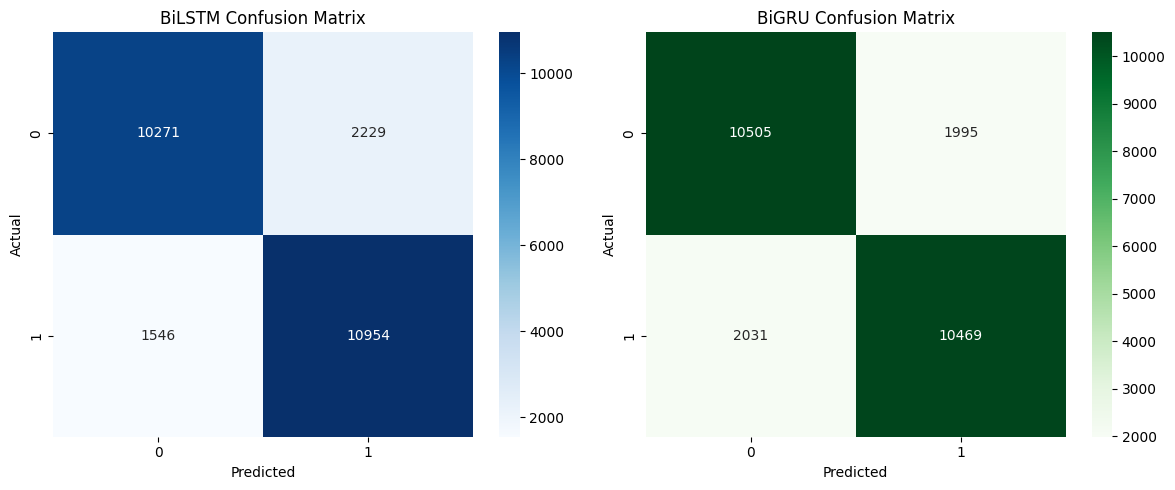

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_test, bilstm_pred)
cm2 = confusion_matrix(y_test, bigru_pred)

sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("BiLSTM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("BiGRU Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 17. ROC curves and AUC

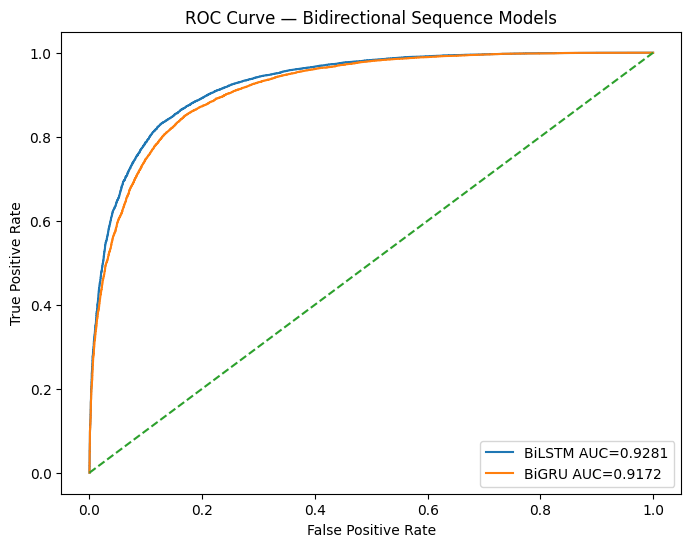

In [18]:
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, bilstm_prob)
fpr_gru, tpr_gru, _ = roc_curve(y_test, bigru_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr_lstm, tpr_lstm, label=f"BiLSTM AUC={bilstm_metrics['AUC']:.4f}")
plt.plot(fpr_gru, tpr_gru, label=f"BiGRU AUC={bigru_metrics['AUC']:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bidirectional Sequence Models")
plt.legend()
plt.show()

## 18. Model comparison

,Accuracy,Precision,Recall,F1,AUC
BiLSTM,0.849,0.8309,0.8763,0.8530,0.9281
BiGRU,0.839,0.8399,0.8375,0.8387,0.9172


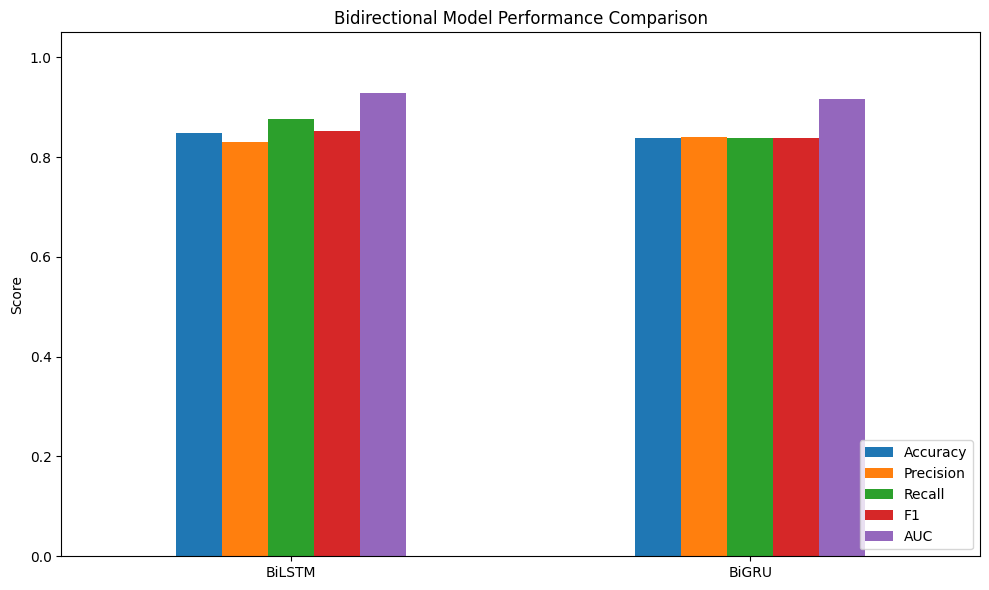

In [19]:
comparison = pd.DataFrame(
    [bilstm_metrics, bigru_metrics],
    index=["BiLSTM", "BiGRU"]
)

display(comparison.round(4))

comparison.plot(kind="bar", figsize=(10,6))
plt.title("Bidirectional Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 19. Prediction function

**Important:** This notebook uses Keras `TextVectorization`, not `Tokenizer`/`tokenizer_lstm`. Therefore inference must pass raw text to the model. The prediction function below uses a TensorFlow string tensor and does not call `texts_to_sequences()`.


In [20]:
def predict_sentiment(text, model=None):
    """
    Predict IMDb sentiment from raw text.

    The model already contains the TextVectorization layer, so raw text
    should be passed directly to the model. We use tf.constant(dtype=tf.string)
    instead of np.array([text]) to avoid NumPy string-dtype issues.
    """
    if model is None:
        model = bilstm_model

    if not isinstance(text, str) or not text.strip():
        raise ValueError("Please provide a non-empty text string.")

    # Keep the input explicitly as TensorFlow string tensors.
    input_tensor = tf.constant([text], dtype=tf.string)

    probability = float(model(input_tensor, training=False).numpy().reshape(-1)[0])

    label = "Positive" if probability >= 0.5 else "Negative"
    confidence = probability if label == "Positive" else 1.0 - probability

    return {
        "sentiment": label,
        "probability_positive": round(probability, 4),
        "probability_negative": round(1.0 - probability, 4),
        "confidence": round(confidence, 4)
    }


examples = [
    "This movie was absolutely wonderful and I loved every minute of it.",
    "The story was boring, the acting was weak, and I hated the ending."
]

for text in examples:
    print("Review:", text)
    print("Prediction:", predict_sentiment(text))
    print("-" * 80)


Review: This movie was absolutely wonderful and I loved every minute of it.
Prediction: {'sentiment': 'Positive', 'probability_positive': 0.898, 'probability_negative': 0.102, 'confidence': 0.898}
--------------------------------------------------------------------------------
Review: The story was boring, the acting was weak, and I hated the ending.
Prediction: {'sentiment': 'Negative', 'probability_positive': 0.1511, 'probability_negative': 0.8489, 'confidence': 0.8489}
--------------------------------------------------------------------------------


## 20. Save final models

In [21]:
bilstm_path = os.path.join(MODEL_DIR, "bilstm_imdb.keras")
bigru_path = os.path.join(MODEL_DIR, "bigru_imdb.keras")

bilstm_model.save(bilstm_path)
bigru_model.save(bigru_path)

print("BiLSTM saved to:", os.path.abspath(bilstm_path))
print("BiGRU saved to :", os.path.abspath(bigru_path))
print("BiLSTM file exists:", os.path.exists(bilstm_path))
print("BiGRU file exists :", os.path.exists(bigru_path))


BiLSTM saved to: /content/models/bilstm_imdb.keras
BiGRU saved to : /content/models/bigru_imdb.keras
BiLSTM file exists: True
BiGRU file exists : True


## 21. Dataset citation

The Hugging Face `stanfordnlp/imdb` dataset is the Large Movie Review Dataset. It contains 25,000 labeled training reviews and 25,000 labeled test reviews, plus 50,000 unlabeled examples. The dataset card attributes the original work to Maas et al. (2011).

Original paper:

Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C. (2011). *Learning Word Vectors for Sentiment Analysis*. ACL-HLT 2011.

Check the Hugging Face dataset card for the current licensing information before redistributing dataset files.

## 22. Reload saved model and test prediction

The saved `.keras` model contains the `TextVectorization` layer, so the original raw text can be passed directly after loading. No separate `tokenizer_lstm` is required for this notebook.

In [22]:
loaded_bilstm = tf.keras.models.load_model(bilstm_path)

test_review = "A fantastic movie with excellent acting and a very engaging story."
print(predict_sentiment(test_review, model=loaded_bilstm))


{'sentiment': 'Positive', 'probability_positive': 0.961, 'probability_negative': 0.039, 'confidence': 0.961}
